Portfolio #1: Exploratory Data Analysis

Dataset Overview: 
Source
This dataset was obtained from Kaggle and contains health and fitness tracking data. 

Description: 
THe dataset includes demographic, physiologial, and workout realted varaibles such as age, gender, height, weight, activity type, duration, calories burned, heart rate, sleep, stress level, daily steps, hydration, BMI, blood pressure, smoking status, and fitness level.

Size: 
After loading the dataset, I found that it contains 687,701 rows and 22 columns. 

Resreach QUestion: 
What fitness and physiological factors are most strongly associated with caloreis burned, and how do workout groups differ in their calorie expenditure?


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
#Where the CSV file is loaded into a panda Dataframe
df = pd.read_csv("health_fitness_dataset.csv")
df.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


In [43]:
#Where Ill check the number of rows and columsn in the dataset
df.shape

(687701, 21)

#Observations:
The dataset contains 687,701 rows and 22 columns. 

In [35]:
df.dtypes

participant_id                int64
date                         object
age                           int64
gender                       object
height_cm                   float64
weight_kg                   float64
activity_type                object
duration_minutes              int64
intensity                    object
calories_burned             float64
avg_heart_rate                int64
hours_sleep                 float64
stress_level                  int64
daily_steps                   int64
hydration_level             float64
bmi                         float64
resting_heart_rate          float64
blood_pressure_systolic     float64
blood_pressure_diastolic    float64
health_condition             object
smoking_status               object
fitness_level               float64
dtype: object

###Observation:
The data set contains both quantitative and categorial variables. 

In [36]:
df.describe()

,participant_id,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
count,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000
mean,1499.781828,41.658602,168.587699,94.921981,70.011671,15.381302,131.454165,7.048799,5.252389,8628.370918,2.499427,22.733134,70.010547,120.001260,80.188079,9.524900
std,865.997215,13.581770,9.140811,22.461801,29.147251,9.985552,17.814744,0.972068,2.770029,2054.756608,0.579050,3.568383,5.074563,10.008917,8.239418,5.502485
min,1.000000,18.000000,145.000000,45.300000,20.000000,0.800000,82.000000,4.000000,1.000000,-419.000000,1.500000,14.200000,51.100000,78.000000,53.700000,0.020000
25%,749.000000,30.000000,161.700000,78.200000,45.000000,7.800000,118.000000,6.400000,3.000000,7203.000000,2.000000,20.100000,66.500000,113.100000,74.600000,4.770000
50%,1499.000000,42.000000,168.200000,94.600000,70.000000,13.000000,130.000000,7.000000,5.000000,8607.000000,2.500000,22.400000,70.000000,120.200000,80.100000,9.510000
75%,2249.000000,53.000000,175.300000,110.500000,95.000000,20.700000,144.000000,7.700000,8.000000,10027.000000,3.000000,25.100000,73.500000,127.000000,85.700000,14.230000
max,3000.000000,64.000000,198.500000,188.400000,120.000000,92.000000,206.000000,10.000000,10.000000,17241.000000,3.500000,38.800000,87.100000,152.700000,112.100000,21.930000


Observation: 
The summary statistics give me a better idea of the overall distribution of the numerical variables. I can see information such as the mean, minimum, maximum, and standard deviation for variables like duration_minutes and calories_burned. These statistics help me understand how much variation there is in workouts and health measurements across participants.

In [37]:
df["activity_type"].value_counts()

activity_type
Yoga               69961
Weight Training    69661
HIIT               69376
Dancing            69193
Cycling            69187
Basketball         68536
Tennis             68533
Walking            68077
Swimming           68032
Running            67145
Name: count, dtype: int64

OBservation: When I looked at the activity_type column, I saw that the dataset includes many different workout types such as yoga, weight training, HIIT, dancing, cycling, basketball, tennis, walking, swimming, and running. The counts appear fairly balanced across these activities, which should make it easier to compare how different workout types affect variables like calories burned.

In [46]:
df.isnull().sum()

participant_id                   0
date                             0
age                              0
gender                           0
height_cm                        0
weight_kg                        0
activity_type                    0
duration_minutes                 0
intensity                        0
calories_burned                  0
avg_heart_rate                   0
hours_sleep                      0
stress_level                     0
daily_steps                      0
hydration_level                  0
bmi                              0
resting_heart_rate               0
blood_pressure_systolic          0
blood_pressure_diastolic         0
health_condition            490275
smoking_status                   0
fitness_level                    0
dtype: int64

Observation: Most of the columns in the dataset do not contain missing values, which suggests that the dataset is relatively clean. However, the health_condition column has a very large number of missing values. Because more than half of the entries in this column are missing, I decided it would be better to remove this column before continuing with the analysis.

In [47]:
#I'll drop health conditions because  it has a lot of data that is missing and it will not be useful for my analysis
df = df.drop(columns=["health_condition"])


Oobservation: I removed the health_condition column because it contained too many missing values to be useful for analysis. Keeping a column with this many missing entries could introduce bias or make the analysis harder to interpret, so removing it helps keep the dataset cleaner.

In [49]:
df.columns

Index(['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg',
       'activity_type', 'duration_minutes', 'intensity', 'calories_burned',
       'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps',
       'hydration_level', 'bmi', 'resting_heart_rate',
       'blood_pressure_systolic', 'blood_pressure_diastolic', 'smoking_status',
       'fitness_level'],
      dtype='object')

SECTION 2:

In [51]:
#Dye to the dataset having over 680,000 rowos I cwill create a smaller random sample of 10,000 rows to make it easier to work with.
df_sample = df.sample(10000, random_state=42)

In [52]:
# Computing correlations between all numerical variables
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,participant_id,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
participant_id,1.000000,-0.005298,-0.006445,-0.002111,-0.001061,-0.001679,0.003281,0.002215,-0.000775,0.000508,-0.000033,-0.001287,0.001343,-0.041515,0.004825,-0.001384
age,-0.005298,1.000000,0.008300,0.032015,0.000903,0.011291,-0.564767,-0.000548,0.000644,-0.000694,0.000978,0.061308,-0.003733,-0.015980,-0.008390,0.002722
height_cm,-0.006445,0.008300,1.000000,0.472808,-0.000917,0.172910,-0.004638,-0.000325,-0.004562,-0.000589,-0.000258,0.343453,0.002921,-0.015442,-0.002393,0.001467
weight_kg,-0.002111,0.032015,0.472808,1.000000,-0.001602,0.365218,-0.017419,-0.001885,-0.002565,-0.343977,-0.000591,0.573853,-0.000297,0.009458,-0.004938,0.761940
duration_minutes,-0.001061,0.000903,-0.000917,-0.001602,1.000000,0.641077,-0.000859,0.002480,0.000485,-0.000005,-0.000291,-0.001404,0.003342,0.001092,0.000330,0.005267
calories_burned,-0.001679,0.011291,0.172910,0.365218,0.641077,1.000000,0.121138,-0.000019,-0.001756,-0.126245,-0.001024,0.210347,-0.000314,0.003279,-0.000322,0.281815
avg_heart_rate,0.003281,-0.564767,-0.004638,-0.017419,-0.000859,0.121138,1.000000,-0.000343,0.000219,-0.000484,0.000175,-0.034370,0.001777,0.008187,0.004926,0.000372
hours_sleep,0.002215,-0.000548,-0.000325,-0.001885,0.002480,-0.000019,-0.000343,1.000000,0.001374,0.001025,0.000609,-0.000651,-0.001156,0.000949,-0.000672,-0.001894
stress_level,-0.000775,0.000644,-0.004562,-0.002565,0.000485,-0.001756,0.000219,0.001374,1.000000,0.000804,0.001050,-0.003107,-0.001499,0.000082,-0.000566,0.000431
daily_steps,0.000508,-0.000694,-0.000589,-0.343977,-0.000005,-0.126245,-0.000484,0.001025,0.000804,1.000000,0.000374,0.000287,-0.000805,0.000437,0.000766,-0.449572


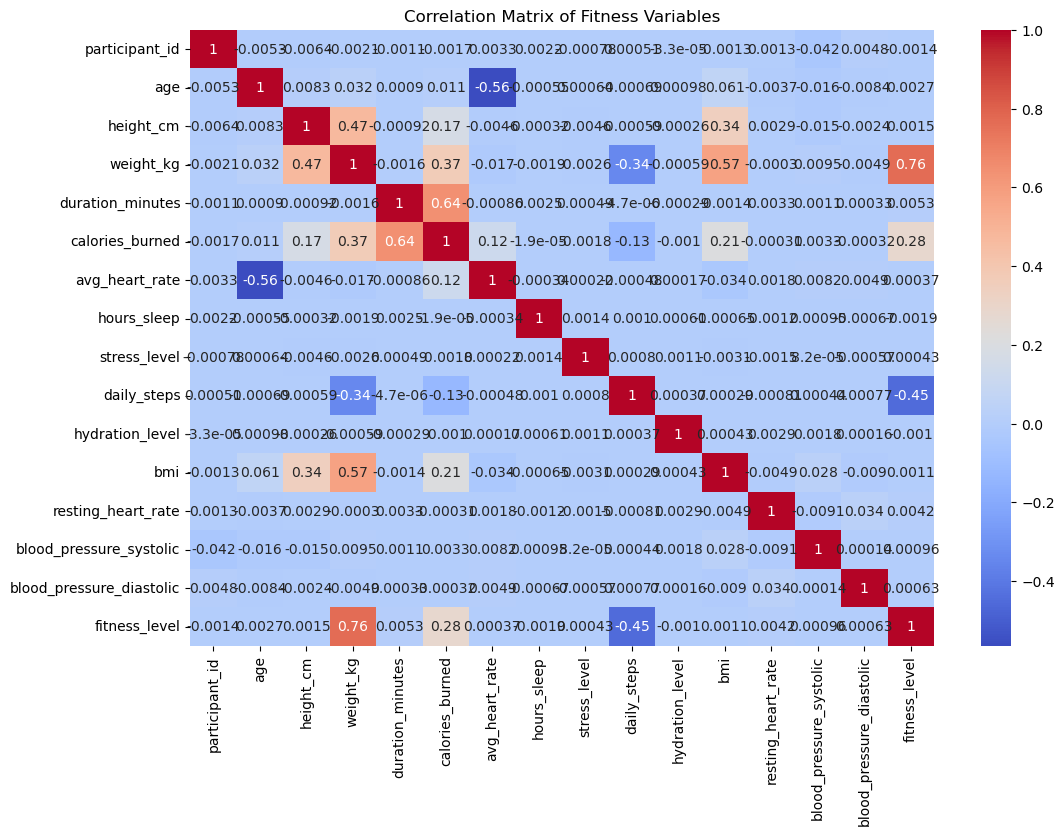

In [53]:
# Visualize correlations with a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Fitness Variables")

plt.show()